In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

%cd /home/smalani/PartialObservations

cwd = os.getcwd()
print(cwd)

/home/smalani/PartialObservations
/home/smalani/PartialObservations


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt

%cd /home/smalani/PartialObservations

cwd = os.getcwd()
print(cwd)

/home/smalani/PartialObservations
/home/smalani/PartialObservations


In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt

%cd /home/smalani/PartialObservations

cwd = os.getcwd()
print(cwd)

/home/smalani/PartialObservations
/home/smalani/PartialObservations


In [4]:
from config import config
from main.utils import Network, MLP
import torch

f = np.load("minmax/minmax.npz")

xmax = f['arr_0']
xmin = f['arr_1']
print(xmax)
print(xmin)

norm_func = lambda input, device: (input - torch.tensor(xmin).float().to(device)) / \
                        ((torch.tensor((xmax - xmin)).float().to(device)) + 1e-10)
inv_norm_func = lambda input, device: input * ((torch.tensor((xmax - xmin)).float().to(device)) + 1e-10) \
                                + torch.tensor(xmin).float().to(device)

# Create the network architecture

if config["MODEL"]["BOX"] == 'Black':
    # Create the network architecture
    mlp = MLP(6, config["MODEL"]["NUM_HIDDEN"], 6)
    
    class my_Network(Network):
        def __init__(self, network, train_size, xdim, norm_func=lambda input, device: input,
                        inv_norm_func=lambda input, device: input, init_available=True, device=None, 
                        tf_prop=1., integrator='RK4', add_par_num=0):
            super(my_Network, self).__init__(network, train_size, xdim, norm_func,
                        inv_norm_func, init_available, device, 
                        tf_prop, integrator, add_par_num)

            self.additional_pars = torch.nn.Parameter((torch.zeros(6)-1).to(self.device), requires_grad = True) 

        def output(self, x, par):

            # ANN_input = torch.cat((self.norm_func(x), par/20), dim=-1)
            ANN_input_out = self.norm_func(x)
            ANN_input = torch.clip(ANN_input_out, min=-1., max=2.)
            out = self.net(ANN_input)
            out = self.inv_norm_func(out) * (100 ** (self.additional_pars))

            return out

elif config["MODEL"]["BOX"] == 'Grey' or config["MODEL"]["BOX"] == 'Gray':
    
    # Create the network architecture
    mlp = MLP(6, config["MODEL"]["NUM_HIDDEN"], 3)
    
    if config["MODEL"]["Parameters"] == 'Trainable':
        class my_Network(Network):
            def __init__(self, network, train_size, xdim, norm_func=lambda input, device: input,
                            inv_norm_func=lambda input, device: input, init_available=True, device=None, 
                            tf_prop=1., integrator='RK4', add_par_num=2):
                super(my_Network, self).__init__(network, train_size, xdim, norm_func,
                            inv_norm_func, init_available, device, 
                            tf_prop, integrator, add_par_num)

                self.additional_pars = torch.nn.Parameter((torch.cat(((torch.tensor([0.4476, -0.4859, -0.6419])), 
                                                                        (torch.zeros(4) + 1)))).to(self.device), 
                                                            requires_grad = True)

            def output(self, x_input, par):
                ANN_input = self.norm_func(x_input)
                ANN_output = self.net(ANN_input)
                ANN_output = ANN_output * (100 ** (self.additional_pars[:3]))

                x, y, z, u, v, g = torch.unbind(x_input, dim=-1)

                u1_prime_x, u2_prime_y, u3_prime_z = torch.unbind(ANN_output, dim=-1)                

                omega = self.additional_pars[-4] * 10
                sigma = self.additional_pars[-3] * 10
                rho = self.additional_pars[-2] / 10
                eta = self.additional_pars[-1]

                alpha, uf, _, _, _, _, _, _, uc1_prime, uc2_prime, uc3_prime = datagen.par_fun()

                output = []

                output.append(-alpha * x + u1_prime_x - uc1_prime * x)
                output.append(-alpha * y + u2_prime_y - uc2_prime * y)
                output.append(-alpha * z + u3_prime_z - uc3_prime * z)
                output.append(alpha * (uf - u) - u1_prime_x)
                output.append(-alpha * v + omega * u1_prime_x - u2_prime_y - sigma * u3_prime_z)
                output.append(-alpha * g + rho * u2_prime_y + eta * u3_prime_z)

                out = torch.stack((output), dim=-1)
                return out
            def raw_output(self, x_input, par):

                ANN_input = self.norm_func(x_input)
                ANN_output = self.net(ANN_input) * (100 ** (self.additional_pars[:3]))

                return ANN_output
    elif config["MODEL"]["Parameters"] == 'Fixed':
        class my_Network(Network):
            def __init__(self, network, train_size, xdim, norm_func=lambda input, device: input,
                            inv_norm_func=lambda input, device: input, init_available=True, device=None, 
                            tf_prop=1., integrator='RK4', add_par_num=2):
                super(my_Network, self).__init__(network, train_size, xdim, norm_func,
                            inv_norm_func, init_available, device, 
                            tf_prop, integrator, add_par_num)

                # self.additional_pars = torch.nn.Parameter((torch.zeros(2)-0.5).to(self.device), 
                #                             requires_grad = True)
                self.additional_pars = torch.nn.Parameter((torch.tensor([0.4476, -0.4859, -0.6419])).to(self.device), 
                                                                requires_grad = True)

                

            def output(self, x_input, par):
                
                ANN_input = self.norm_func(x_input)
                ANN_output = self.net(ANN_input)
                ANN_output = ANN_output * (100 ** (self.additional_pars))

                x, y, z, u, v, g = torch.unbind(x_input, dim=-1)
                u1_prime_x, u2_prime_y, u3_prime_z = torch.unbind(ANN_output, dim=-1)

                alpha, uf, omega, sigma, rho, eta, phi1, phi2, uc1_prime, uc2_prime, uc3_prime = datagen.par_fun(D=1/7.3, sf=2.5)

                output = []

                # output.append(-alpha * x + u1_prime * x - uc1_prime * x)
                # output.append(torch.zeros(output[-1].shape).to(self.device))
                # output.append(-alpha * z + u3_prime * z - uc3_prime * z)
                # output.append(alpha * (uf - u) - u1_prime * x)
                # output.append(-alpha * v + omega * u1_prime * x - u2_prime * y - sigma * u3_prime * z)
                # output.append(-alpha * g + rho * u2_prime * y + eta * u3_prime * z)

                output.append(-alpha * x + u1_prime_x - uc1_prime * x)

                output.append(-alpha * y + u2_prime_y - uc2_prime * y)
                # output.append(torch.zeros(output[-1].shape).to(self.device))

                output.append(-alpha * z + u3_prime_z - uc3_prime * z)
                output.append(alpha * (uf - u) - u1_prime_x)
                output.append(-alpha * v + omega * u1_prime_x - u2_prime_y - sigma * u3_prime_z)
                output.append(-alpha * g + rho * u2_prime_y + eta * u3_prime_z)

                out = torch.stack((output), dim=-1)
                return out
            def raw_output(self, x_input, par):

                ANN_input = self.norm_func(x_input)
                ANN_output = self.net(ANN_input) * (100 ** (self.additional_pars))

                return ANN_output

    else:
        raise ValueError("Tell me whether to train the parameters!")
else:
    raise ValueError("Tell me what box to use!")


network = my_Network(mlp, config["DATA"]["N_TRAIN"], 6, norm_func=norm_func, inv_norm_func=inv_norm_func, 
                      init_available=config["DATA"]["INIT_AVAILABLE"], integrator='RK4')
device = 'cpu'

filename = 'data/' + 'model_' + '.net'

print(filename)


state_dict = torch.load(filename, map_location=torch.device(device))
network.load_state_dict(state_dict, strict=False)

print(network)
network.double()

[7.76480999e+01 6.13450077e-02 3.52889567e-01 2.08507400e+02
 2.11354658e+03 8.21362308e-01]
[1.45181035e+01 1.12344629e-04 2.81247634e-01 3.24970859e+01
 3.97881635e+02 6.58996734e-01]
data/model_.net
my_Network(
  (net): MLP(
    (layers): ModuleList(
      (0): Linear(in_features=6, out_features=32, bias=True)
      (1): Linear(in_features=32, out_features=32, bias=True)
    )
    (activation): SiLU()
    (output_layer): Linear(in_features=32, out_features=6, bias=True)
  )
)


my_Network(
  (net): MLP(
    (layers): ModuleList(
      (0): Linear(in_features=6, out_features=32, bias=True)
      (1): Linear(in_features=32, out_features=32, bias=True)
    )
    (activation): SiLU()
    (output_layer): Linear(in_features=32, out_features=6, bias=True)
  )
)

In [ ]:
f = np.load('minmax/limitcycle_50.npz')
myvar0 = f['arr_0']


f = np.load('minmax/limitcycle_detail.npz')
myvar0_detail = f['arr_0']

print(myvar0.shape)
print(myvar0_detail.shape)

(6, 50)


In [16]:
from scipy.integrate import solve_ivp
from BandFModel.datagen import ode_fun

def ode_NN_func(t,x,p):
    x_in = torch.tensor(x).reshape((-1,6)).to(network.device)
    p_in = torch.tensor(p).reshape((-1,1)).to(network.device)
    return network.output(x_in, p_in).cpu().detach().numpy()

[5.00000000e+01 9.47035345e-28 2.85187797e-01 1.20150526e+02
 1.25440965e+03 6.62657291e-01]


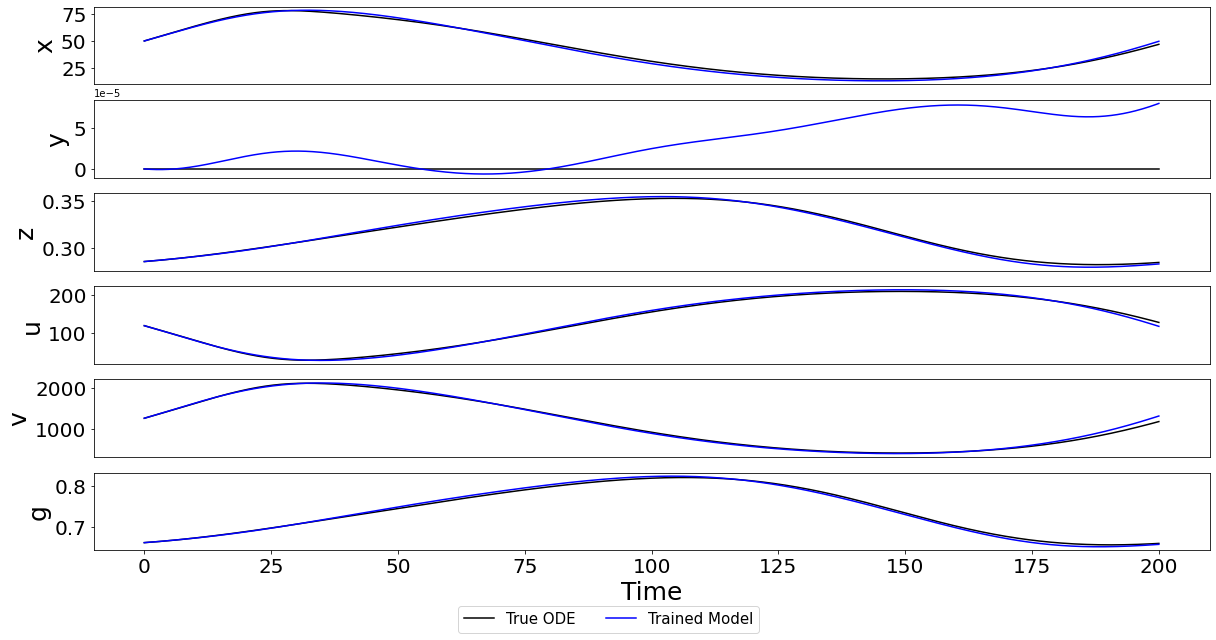

In [17]:
from BandFModel import datagen

init = myvar0[:,0]
print(init)

pars = datagen.par_fun()

T=200
# init[1] = 0
teval = np.linspace(0,T,1000)

sol_true = solve_ivp(ode_fun, y0=init, t_span=[0, T],
                        t_eval=teval, args=(pars,),
                        rtol=1e-5, atol=1e-8)

sol_pred = solve_ivp(ode_NN_func, y0=init, t_span=[0, T],
                        t_eval=teval, args=([6]),
                        rtol=1e-5, atol=1e-8)

fig = plt.figure(figsize=(20,10))
labels = ['x', 'y', 'z', 'u', 'v', 'g']
for i in range(6):
    ax = plt.subplot(int(str(61) + str(i+1)))
    ax.plot(sol_true.t, sol_true.y[i,:], 'k', label='True ODE')
    ax.plot(sol_pred.t, sol_pred.y[i,:], 'b', label='Trained Model')
    ax.set_ylabel(labels[i], color='k', fontsize=25)
    ax.tick_params(axis='y', labelsize=20)                              
    if i<5:
        ax.set_xticks([])
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=4, fontsize=15)

# np.savez('minmax/limitcycle.npz', sol_true.y)
    
plt.xlabel('Time', fontsize=25)
ax.tick_params(axis='x', labelsize=20)

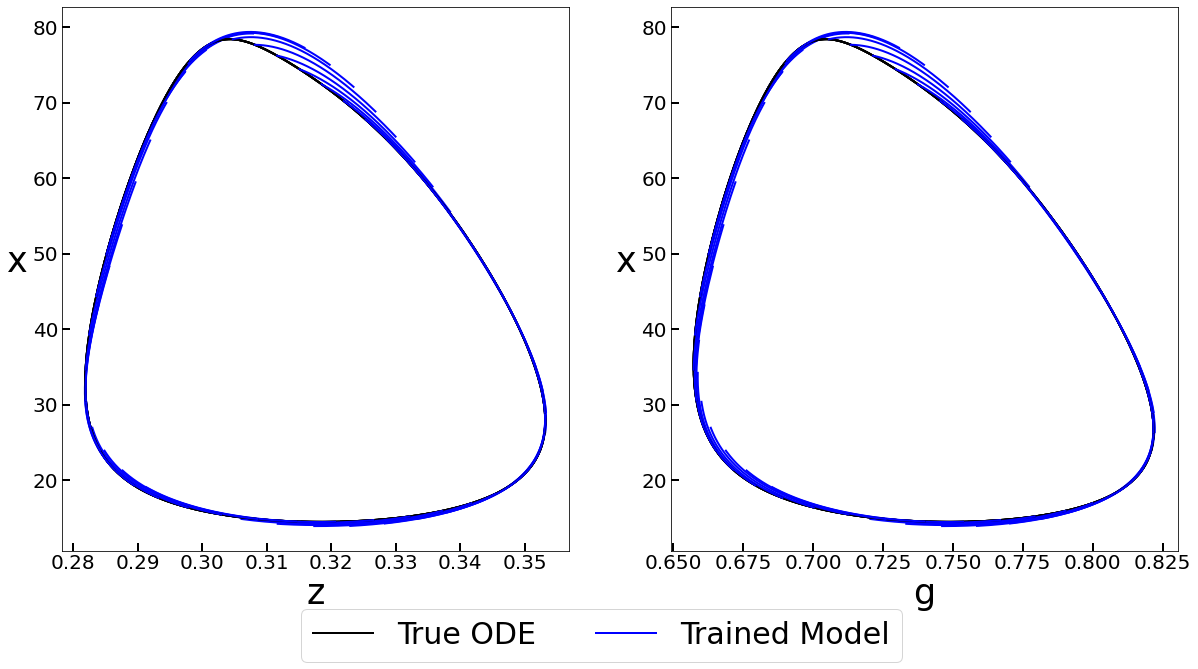

In [18]:
fig = plt.figure(figsize=(20,10))
axes = []
labels = ['x', 'y', 'z', 'u', 'v', 'g']
for i in range(2):
    axes.append(plt.subplot(int(str(12) + str(i+1))))

RHS_hair_error_trueLC_True = []
RHS_hair_error_trueLC_Pred = []

for j in range(myvar0.shape[1]):
    init = myvar0[:,j]
    # print(init)

    pars = datagen.par_fun()

    T=20
    # init[1] = 0
    teval = np.linspace(0,T,1000)

    sol_true = solve_ivp(ode_fun, y0=init, t_span=[0, T],
                            t_eval=teval, args=(pars,),
                            rtol=1e-5, atol=1e-8)

    sol_pred = solve_ivp(ode_NN_func, y0=init, t_span=[0, T],
                            t_eval=teval, args=([6]),
                            rtol=1e-5, atol=1e-8)
    # error = np.sqrt((sol_pred[:,-1] - sol_true[:,-1]) ** 2) / myvar0.shape[1]
    # print(error.shape)
    RHS_hair_error_trueLC_True.append(sol_true.y[:,-1])
    RHS_hair_error_trueLC_Pred.append(sol_pred.y[:,-1])
    # RHS_hair_error_true += np.sum((np.sqrt((sol_pred.y[:,-1] - sol_true.y[:,-1]) ** 2) / myvar0.shape[1]) / xmax)
    # RHS_hair_error_true_arr += (sol_pred.y[:,-1] - sol_true.y[:,-1]) ** 2

    axes[0].plot(sol_true.y[2,:],sol_true.y[0,:], 'k', label='True ODE', linewidth=2)
    axes[0].plot(sol_pred.y[2,:],sol_pred.y[0,:], 'b', label='Trained Model', linewidth=2)
    axes[0].set_ylabel('x  ', color='k', fontsize=35, rotation=0)
    axes[0].tick_params(axis='y', labelsize=20, direction='in', length=8, width=2)
    axes[0].set_xlabel('z', color='k', fontsize=35)
    axes[0].tick_params(axis='x', labelsize=20, direction='in', length=8, width=2)


    axes[1].plot(sol_true.y[5,:],sol_true.y[0,:], 'k', label='True ODE', linewidth=2)
    axes[1].plot(sol_pred.y[5,:],sol_pred.y[0,:], 'b', label='Trained Model', linewidth=2)
    axes[1].set_ylabel('x  ', color='k', fontsize=35, rotation=0)
    axes[1].tick_params(axis='y', labelsize=20, direction='in', length=8, width=2)
    axes[1].set_xlabel('g', color='k', fontsize=35)
    axes[1].tick_params(axis='x', labelsize=20, direction='in', length=8, width=2)
    # for i in range(6):
    #     axes[i].plot(sol_true.t, sol_true.y[i,:], 'k', label='True ODE')
    #     axes[i].plot(sol_pred.t, sol_pred.y[i,:], 'b', label='Trained Model')    
    #     axes[i].set_ylabel(labels[i], color='k', fontsize=25)
    #     axes[i].tick_params(axis='y', labelsize=20)                              
    #     if i<5:
    #         ax.set_xticks([])
handles, labels = axes[0].get_legend_handles_labels()
# fig.legend(handles[:2], labels[:2], loc='lower center', ncol=4, fontsize=30)
leg = fig.legend(handles[:2], labels[:2], loc='lower center', ncol=2, fontsize=30, bbox_to_anchor= (0.5, -0.05))
# np.savez('minmax/limitcycle.npz', sol_true.y)
    
# plt.xlabel('Time', fontsize=25)
# ax.tick_params(axis='x', labelsize=20)
RHS_hair_error_trueLC_True = np.vstack(RHS_hair_error_trueLC_True)
RHS_hair_error_trueLC_Pred = np.vstack(RHS_hair_error_trueLC_Pred)

In [19]:
RHSError_trueLC_L1Norm = np.sum(np.average(np.abs(RHS_hair_error_trueLC_True - RHS_hair_error_trueLC_Pred), axis=0) / (xmax))
RHSError_trueLC_L2Norm = np.sum(np.sqrt(np.sum((RHS_hair_error_trueLC_True - RHS_hair_error_trueLC_Pred)**2, axis=0)) / (myvar0.shape[1] * xmax))
RHSError_trueLC_LinfNorm = np.sum(np.max(np.abs(RHS_hair_error_trueLC_True - RHS_hair_error_trueLC_Pred), axis=0) / (xmax))
print(RHSError_trueLC_L1Norm)
print(RHSError_trueLC_L2Norm)
print(RHSError_trueLC_LinfNorm)

0.02364597290631544
0.004556629282069677
0.08879410018355167


In [20]:
from BandFModel import datagen
from BandFModel.datagen import ode_fun, par_fun
from scipy.optimize import fsolve
from scipy.integrate import solve_ivp

pars = par_fun()

def ode_NN_func(t,x,p):
    x_in = torch.tensor(x).reshape((-1,6)).to(network.device)
    p_in = torch.tensor(p).reshape((-1,1)).to(network.device)
    return network.output(x_in, p_in).cpu().detach().numpy()

def fsolve_fun_pred(var):
    T = var[0]
    init = np.array([50])
    init = np.concatenate((init,var[1:]))


    sol = solve_ivp(ode_NN_func, y0=init, t_span=[0, 0.1],
                    args=([6]),
                    rtol=1e-5, atol=1e-8)

    sol = solve_ivp(ode_NN_func, y0=sol.y[:,-1], t_span=[0, T],
                        args=([6]),
                        rtol=1e-5, atol=1e-8)

    return sol.y[:,-1] - init

fsolve_guess = np.array([150, 0, 0.33, 100, 1000, 0.75])
# fsolve_guess = myvar0[:,0]
# fsolve_guess[0] = 200
root_pred = fsolve(fsolve_fun_pred, fsolve_guess)
print(root_pred)

init = np.array([50])
init = np.concatenate((init, root_pred[1:]))
T = root_pred[0]
# init[1] = 0
teval = np.linspace(0,T,100)

sol_pred = solve_ivp(ode_NN_func, y0=init, t_span=[0, T],
                        t_eval=teval, args=([6]),
                        rtol=1e-5, atol=1e-8)

[1.94590062e+02 1.01269435e-03 3.01406175e-01 9.15998533e+01
 1.61343483e+03 5.78284259e-01]


In [21]:
print(sol_pred.y.shape)
print(myvar0.shape)

myvar0 = sol_pred.y

(6, 100)
(6, 50)


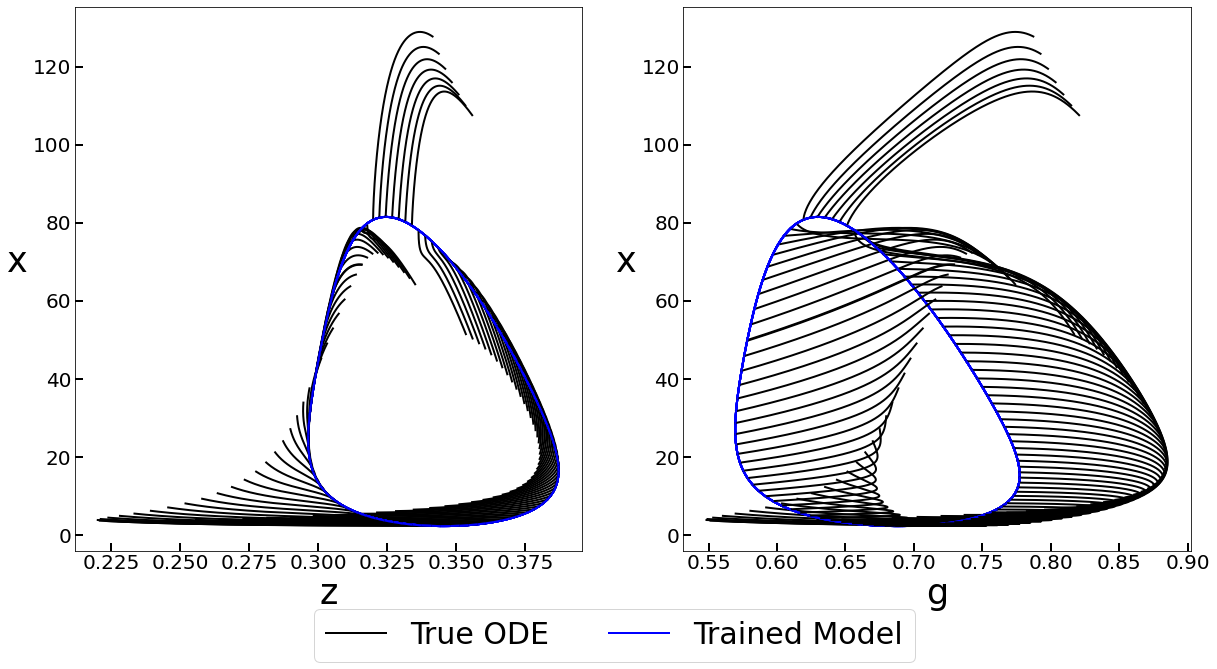

In [22]:
fig = plt.figure(figsize=(20,10))
axes = []
labels = ['x', 'y', 'z', 'u', 'v', 'g']
for i in range(2):
    axes.append(plt.subplot(int(str(12) + str(i+1))))

RHS_hair_error_predLC_True = []
RHS_hair_error_predLC_Pred = []

for j in range(myvar0.shape[1]):
    init = myvar0[:,j]
    # print(init)

    pars = datagen.par_fun()

    T=20
    # init[1] = 0
    teval = np.linspace(0,T,1000)

    sol_true = solve_ivp(ode_fun, y0=init, t_span=[0, T],
                            t_eval=teval, args=(pars,),
                            rtol=1e-5, atol=1e-8)

    sol_pred = solve_ivp(ode_NN_func, y0=init, t_span=[0, T],
                            t_eval=teval, args=([6]),
                            rtol=1e-5, atol=1e-8)
    # error = np.sqrt((sol_pred[:,-1] - sol_true[:,-1]) ** 2) / myvar0.shape[1]
    # print(error.shape)
    RHS_hair_error_predLC_True.append(sol_true.y[:,-1])
    RHS_hair_error_predLC_Pred.append(sol_pred.y[:,-1])
    # RHS_hair_error_pred += np.sum((np.sqrt((sol_pred.y[:,-1] - sol_true.y[:,-1]) ** 2) / myvar0.shape[1]) / xmax)
    # RHS_hair_error_pred_arr += (sol_pred.y[:,-1] - sol_true.y[:,-1]) ** 2

    axes[0].plot(sol_true.y[2,:],sol_true.y[0,:], 'k', label='True ODE', linewidth=2)
    axes[0].plot(sol_pred.y[2,:],sol_pred.y[0,:], 'b', label='Trained Model', linewidth=2)
    axes[0].set_ylabel('x  ', color='k', fontsize=35, rotation=0)
    axes[0].tick_params(axis='y', labelsize=20, direction='in', length=8, width=2)
    axes[0].set_xlabel('z', color='k', fontsize=35)
    axes[0].tick_params(axis='x', labelsize=20, direction='in', length=8, width=2)


    axes[1].plot(sol_true.y[5,:],sol_true.y[0,:], 'k', label='True ODE', linewidth=2)
    axes[1].plot(sol_pred.y[5,:],sol_pred.y[0,:], 'b', label='Trained Model', linewidth=2)
    axes[1].set_ylabel('x  ', color='k', fontsize=35, rotation=0)
    axes[1].tick_params(axis='y', labelsize=20, direction='in', length=8, width=2)
    axes[1].set_xlabel('g', color='k', fontsize=35)
    axes[1].tick_params(axis='x', labelsize=20, direction='in', length=8, width=2)
    # for i in range(6):
    #     axes[i].plot(sol_true.t, sol_true.y[i,:], 'k', label='True ODE')
    #     axes[i].plot(sol_pred.t, sol_pred.y[i,:], 'b', label='Trained Model')    
    #     axes[i].set_ylabel(labels[i], color='k', fontsize=25)
    #     axes[i].tick_params(axis='y', labelsize=20)                              
    #     if i<5:
    #         ax.set_xticks([])
handles, labels = axes[0].get_legend_handles_labels()
# fig.legend(handles[:2], labels[:2], loc='lower center', ncol=4, fontsize=30)
leg = fig.legend(handles[:2], labels[:2], loc='lower center', ncol=2, fontsize=30, bbox_to_anchor= (0.5, -0.05))

# np.savez('minmax/limitcycle.npz', sol_true.y)
    
# plt.xlabel('Time', fontsize=25)
ax.tick_params(axis='x', labelsize=20)
# RHS_hair_error_pred_arr_calc = np.sum(np.sqrt(RHS_hair_error_pred_arr) / (myvar0.shape[1] * xmax))

RHS_hair_error_predLC_True = np.vstack(RHS_hair_error_predLC_True)
RHS_hair_error_predLC_Pred = np.vstack(RHS_hair_error_predLC_Pred)

In [23]:
RHSError_predLC_L1Norm = np.sum(np.average(np.abs(RHS_hair_error_predLC_True - RHS_hair_error_predLC_Pred), axis=0) / (xmax))
RHSError_predLC_L2Norm = np.sum(np.sqrt(np.sum((RHS_hair_error_predLC_True - RHS_hair_error_predLC_Pred)**2, axis=0)) / (myvar0.shape[1] * xmax))
RHSError_predLC_LinfNorm = np.sum(np.max(np.abs(RHS_hair_error_predLC_True - RHS_hair_error_predLC_Pred), axis=0) / (xmax))
print(RHSError_trueLC_L1Norm)
print(RHSError_trueLC_L2Norm)
print(RHSError_trueLC_LinfNorm)
print('======================')
print(RHSError_predLC_L1Norm)
print(RHSError_predLC_L2Norm)
print(RHSError_predLC_LinfNorm)